# Gender recognition by analyzing voice and speech

The database was created with the intention of identifying male or female voice. The following accostic properties are used as features:

meanfreq: mean frequency (in kHz)

sd: standard deviation of frequency

median: median frequency (in kHz)

Q25: first quantile (in kHz)

Q75: third quantile (in kHz)

IQR: interquantile range (in kHz)

skew: skewness (see note in specprop description)

kurt: kurtosis (see note in specprop description)

sp.ent: spectral entropy

sfm: spectral flatness

mode: mode frequency

centroid: frequency centroid (see specprop)

peakf: peak frequency (frequency with highest energy)

meanfun: average of fundamental frequency measured across acoustic signal

minfun: minimum fundamental frequency measured across acoustic signal

maxfun: maximum fundamental frequency measured across acoustic signal

meandom: average of dominant frequency measured across acoustic signal

mindom: minimum of dominant frequency measured across acoustic signal

maxdom: maximum of dominant frequency measured across acoustic signal

dfrange: range of dominant frequency measured across acoustic signal

modindx: modulation index

The target is specified by the column label, which takes values male or female.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn import metrics

## Loading dataset
Source : https://www.kaggle.com/primaryobjects/voicegender

In [ ]:
!wget 'https://raw.githubusercontent.com/profsarang/ThinkingDataScience/main/data/voice.csv'

--2025-11-10 14:54:57--  https://raw.githubusercontent.com/profsarang/ThinkingDataScience/main/data/voice.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1065381 (1.0M) [text/plain]
Saving to: ‘voice.csv.1’

voice.csv.1         100%[===================>]   1.02M  --.-KB/s    in 0.04s   

2025-11-10 14:54:57 (25.2 MB/s) - ‘voice.csv.1’ saved [1065381/1065381]



In [ ]:
df=pd.read_csv('/content/voice.csv')

In [ ]:
df

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3163,0.131884,0.084734,0.153707,0.049285,0.201144,0.151859,1.762129,6.630383,0.962934,0.763182,...,0.131884,0.182790,0.083770,0.262295,0.832899,0.007812,4.210938,4.203125,0.161929,female
3164,0.116221,0.089221,0.076758,0.042718,0.204911,0.162193,0.693730,2.503954,0.960716,0.709570,...,0.116221,0.188980,0.034409,0.275862,0.909856,0.039062,3.679688,3.640625,0.277897,female
3165,0.142056,0.095798,0.183731,0.033424,0.224360,0.190936,1.876502,6.604509,0.946854,0.654196,...,0.142056,0.209918,0.039506,0.275862,0.494271,0.007812,2.937500,2.929688,0.194759,female
3166,0.143659,0.090628,0.184976,0.043508,0.219943,0.176435,1.591065,5.388298,0.950436,0.675470,...,0.143659,0.172375,0.034483,0.250000,0.791360,0.007812,3.593750,3.585938,0.311002,female


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

In this datset there are 3168 records and 21 variables


In [ ]:
df.isnull().sum()

,0
meanfreq,0
sd,0
median,0
Q25,0
Q75,0
IQR,0
skew,0
kurt,0
sp.ent,0
sfm,0


There are no missing values in the dataset

## Extracting features and target

In [ ]:
X= df.iloc[:,:-1]
Y= df.iloc[:,-1]

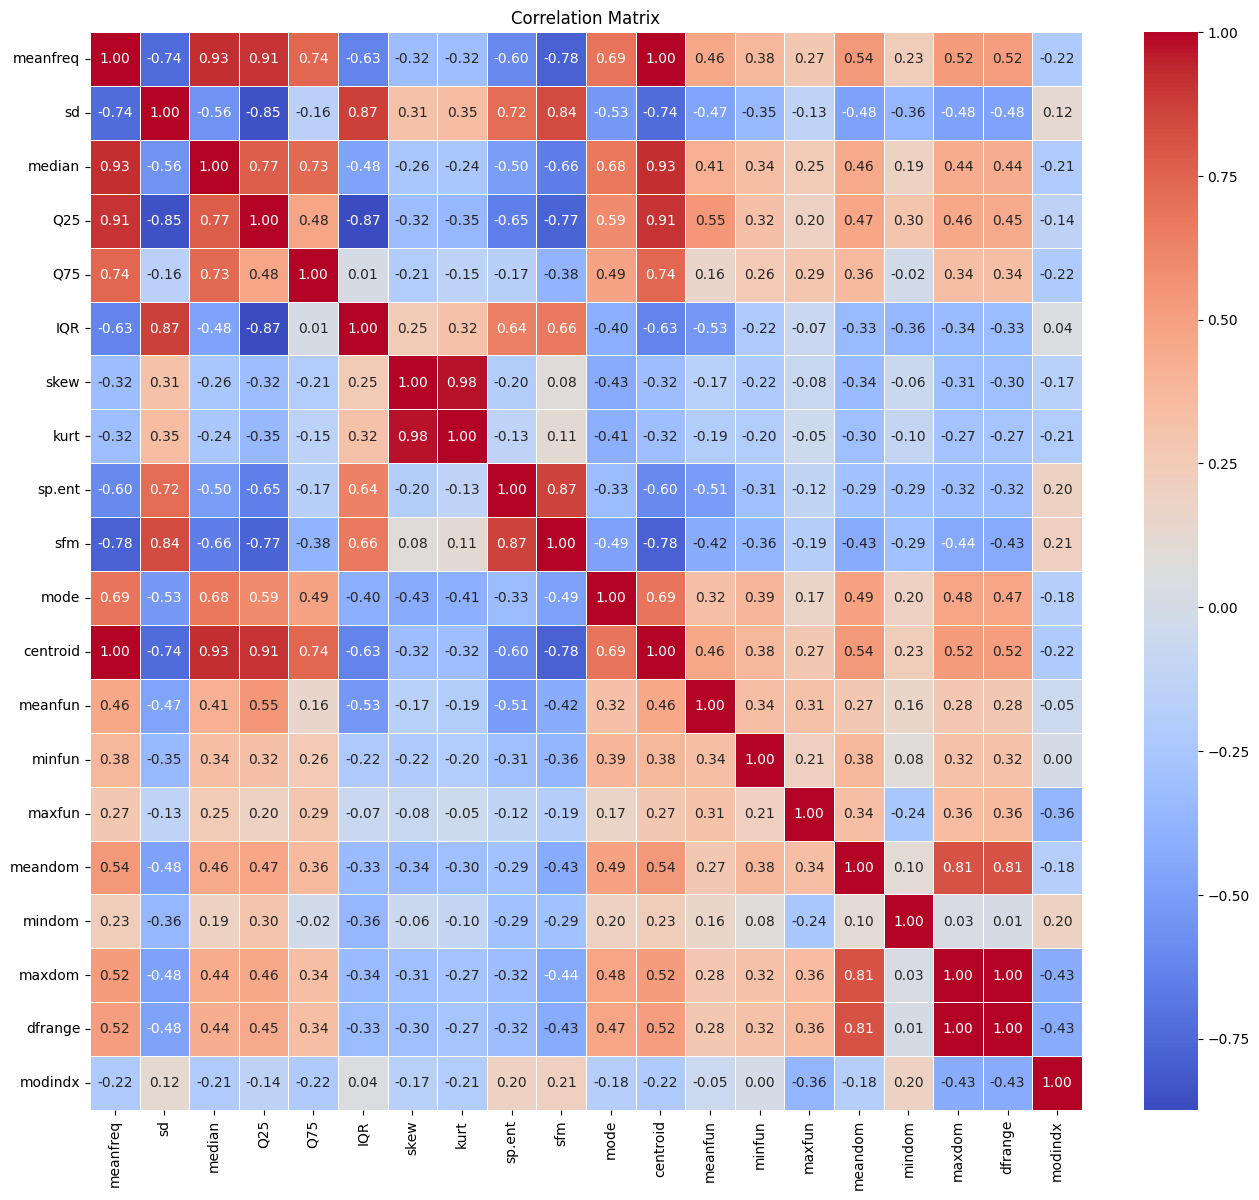

In [ ]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

## Encoding labels

LabelEncoder is a class from scikit-learn (sklearn.preprocessing) used to convert categorical labels (text or strings) into numeric values.

➡️ In machine learning, algorithms can’t process text directly — they need numbers.
So LabelEncoder is used to convert categories into numbers automatically.

In [ ]:
enc_gender = LabelEncoder()#Here, you create an object called enc_gender.
                          #This object knows how to map text labels to numbers.
y = enc_gender.fit_transform(Y)

This line does two things at once:(y = enc_gender.fit_transform(Y))

fit() → The encoder learns all the unique categories in Y.
In our example: ['Female', 'Male', 'Other']

transform() → It then replaces each label with a number:

Female → 0
Male   → 1
Other  → 2

y = [1, 0, 0, 1, 2]

✅ Now y is numeric and ready for use in a machine learning model (like logistic regression, decision tree, etc.).



## Scaling

This code standardizes (scales) your feature data X so that it has:

Mean = 0

Standard deviation = 1

👉 It helps machine learning algorithms work better and converge faster (especially those sensitive to feature scales, like SVM, KNN, neural networks, etc.).

In [ ]:
# Scale the data to be between -1 and 1
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler.fit(X)
X = std_scaler.transform(X)

Compute mean and standard deviation

For each column (feature):

Feature 1:

Mean = (10 + 20 + 30) / 3 = 20

Std = √(((10–20)² + (20–20)² + (30–20)²) / 3) = √(200/3) ≈ 8.165

Feature 2:

Mean = (100 + 200 + 300) / 3 = 200

Std = √(((100–200)² + (200–200)² + (300–200)²) / 3) = √(20000/3) ≈ 81.65
Compute each column separately:

Row	Feature 1	Feature 2

1	(10 − 20) / 8.165 = −1.2247	(100 − 200) / 81.65 = −1.2247
2	(20 − 20) / 8.165 = 0	(200 − 200) / 81.65 = 0
3	(30 − 20) / 8.165 = +1.2247	(300 − 200) / 81.65 = +1.2247

✅ Result
[[-1.2247 -1.2247]
 [ 0.      0.    ]
 [ 1.2247  1.2247]]

## Creating training and test datasets  

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

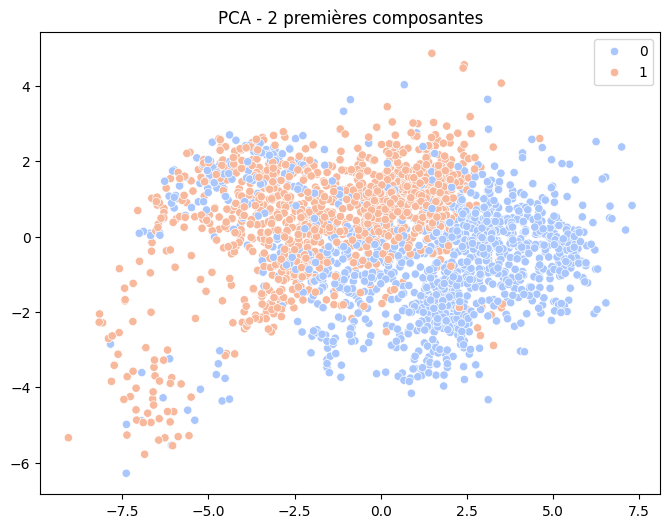

In [ ]:
# PCA pour 95% de la variance
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


# Visualisation des deux premières composantes
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_train_pca[:,0], y=X_train_pca[:,1], hue=y_train, palette='coolwarm')
plt.title('PCA - 2 premières composantes')
plt.show()

## Running SVM with default hyperparameters

In [ ]:
svc_default = SVC()
svc_default.fit(X_train,y_train)
y_pred = svc_default.predict(X_test)
print("Accuracy Score:")
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.9826498422712934


## Effect of different kernels

### Linear kernel

In [ ]:
svc_linear=SVC(kernel='linear')
svc_linear.fit(X_train,y_train)
y_pred=svc_linear.predict(X_test)
print('Accuracy score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy score:
0.9747634069400631


### RBF kernel

In [ ]:
svc_RBF= SVC(kernel='rbf')
svc_RBF.fit(X_train,y_train)
y_pred =svc_RBF.predict(X_test)
print("Accuracy score: ")
print(metrics.accuracy_score(y_test,y_pred))

Accuracy score: 
0.9826498422712934


### Polynomial kernel

In [ ]:
svc_poly=SVC(kernel='poly')
svc_poly.fit(X_train,y_train)
y_pred=svc_poly.predict(X_test)
print('Accuracy score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy score:
0.9574132492113565


## Performance matrix

In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion matrix\n\n', conf_matrix)

Confusion matrix

 [[293  24]
 [  3 314]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.92      0.96       317
           1       0.93      0.99      0.96       317

    accuracy                           0.96       634
   macro avg       0.96      0.96      0.96       634
weighted avg       0.96      0.96      0.96       634

